# ARGUS-FEDER on JupyterHub — Pelican Data Access, Metadata, and PTDATA Basics

This notebook demonstrates ARGUS answering natural-language questions about
DIII-D data through several different access paths: semantic concept →
MDSplus signal resolution, the shot-metadata database, PTDATA (a separate
raw-digitizer data source), and IMAS (the device-neutral naming standard).
Each `%%ask` cell sends a plain-English request; ARGUS consults the DIII-D
skills, writes and runs the code, and reports back.

JupyterHub counterpart of **`argus_feder_pelican_database_ptdata_colab.ipynb`**.
Every `%%ask` request is identical to the Colab version, so the two can be
compared directly.

**Prerequisites.** The image already has TokSearch, ARGUS and the DIII-D skills
installed -- there is no install step and no `pip`/`conda` cell in this notebook.
You need two things in place:

1. **LLM key** -- `NRP_API_KEY` in the environment, or a `.env` holding it in the
   working directory. ARGUS re-reads that `.env` on every `%%ask`.
2. **Pelican token** -- save it to
   `~/work/_User-Persistent-Storage_CephBlock_/.fdp/token` (survives pod restarts;
   `~/.fdp/token` also works but is wiped when the pod recycles). If the kernel was
   already running when you added it, call `reload_pelican()` -- no restart needed.

Then run the `%reset` cell below and any `%%ask` cell, in any order.


In [ ]:
%reset

## 1. Semantic concept → signal mapping

**Purpose:** can ARGUS resolve a physics CONCEPT to the right MDSplus signal with
no symbol name given? Each request below deliberately omits the `\name`.
then short per-item lines, e.g.:

### Plasma current

I'll consult the shot-fetcher skill since this is a DIII-D EFIT signal fetch.

The skill provides a verified canonical fetch script. I'll write a script that fetches `\ipmhd` from efit01 for shot 165340, computes the stats, and saves a static plot.

I spotted a potential mathtext issue in the label (`&#36;\I_p&#36;` isn't valid). Let me fix the plot labels before running.

Running the fetch script via the required fdp wrapper.

Retrying without the timeout parameter.

The fetch succeeded. Let me verify the plot was saved correctly.

Fetched `\ipmhd` (plasma current) from the `efit01` MDSplus tree for shot **165340** .

**Results:**

| Metric | Value |
|---|---|
| **Signal** | `\ipmhd` (EFIT01 computed equilibrium plasma current) |
| **Samples** | 311 |
| **Min** | 2.9202 × 10⁵ A (~0.29 MA) |
| **Max** | 1.1878 × 10⁶ A (~1.19 MA) |
| **Units** | A (amperes; raw signal) |
| **Time span** | 100.0 – 6360.0 ms |


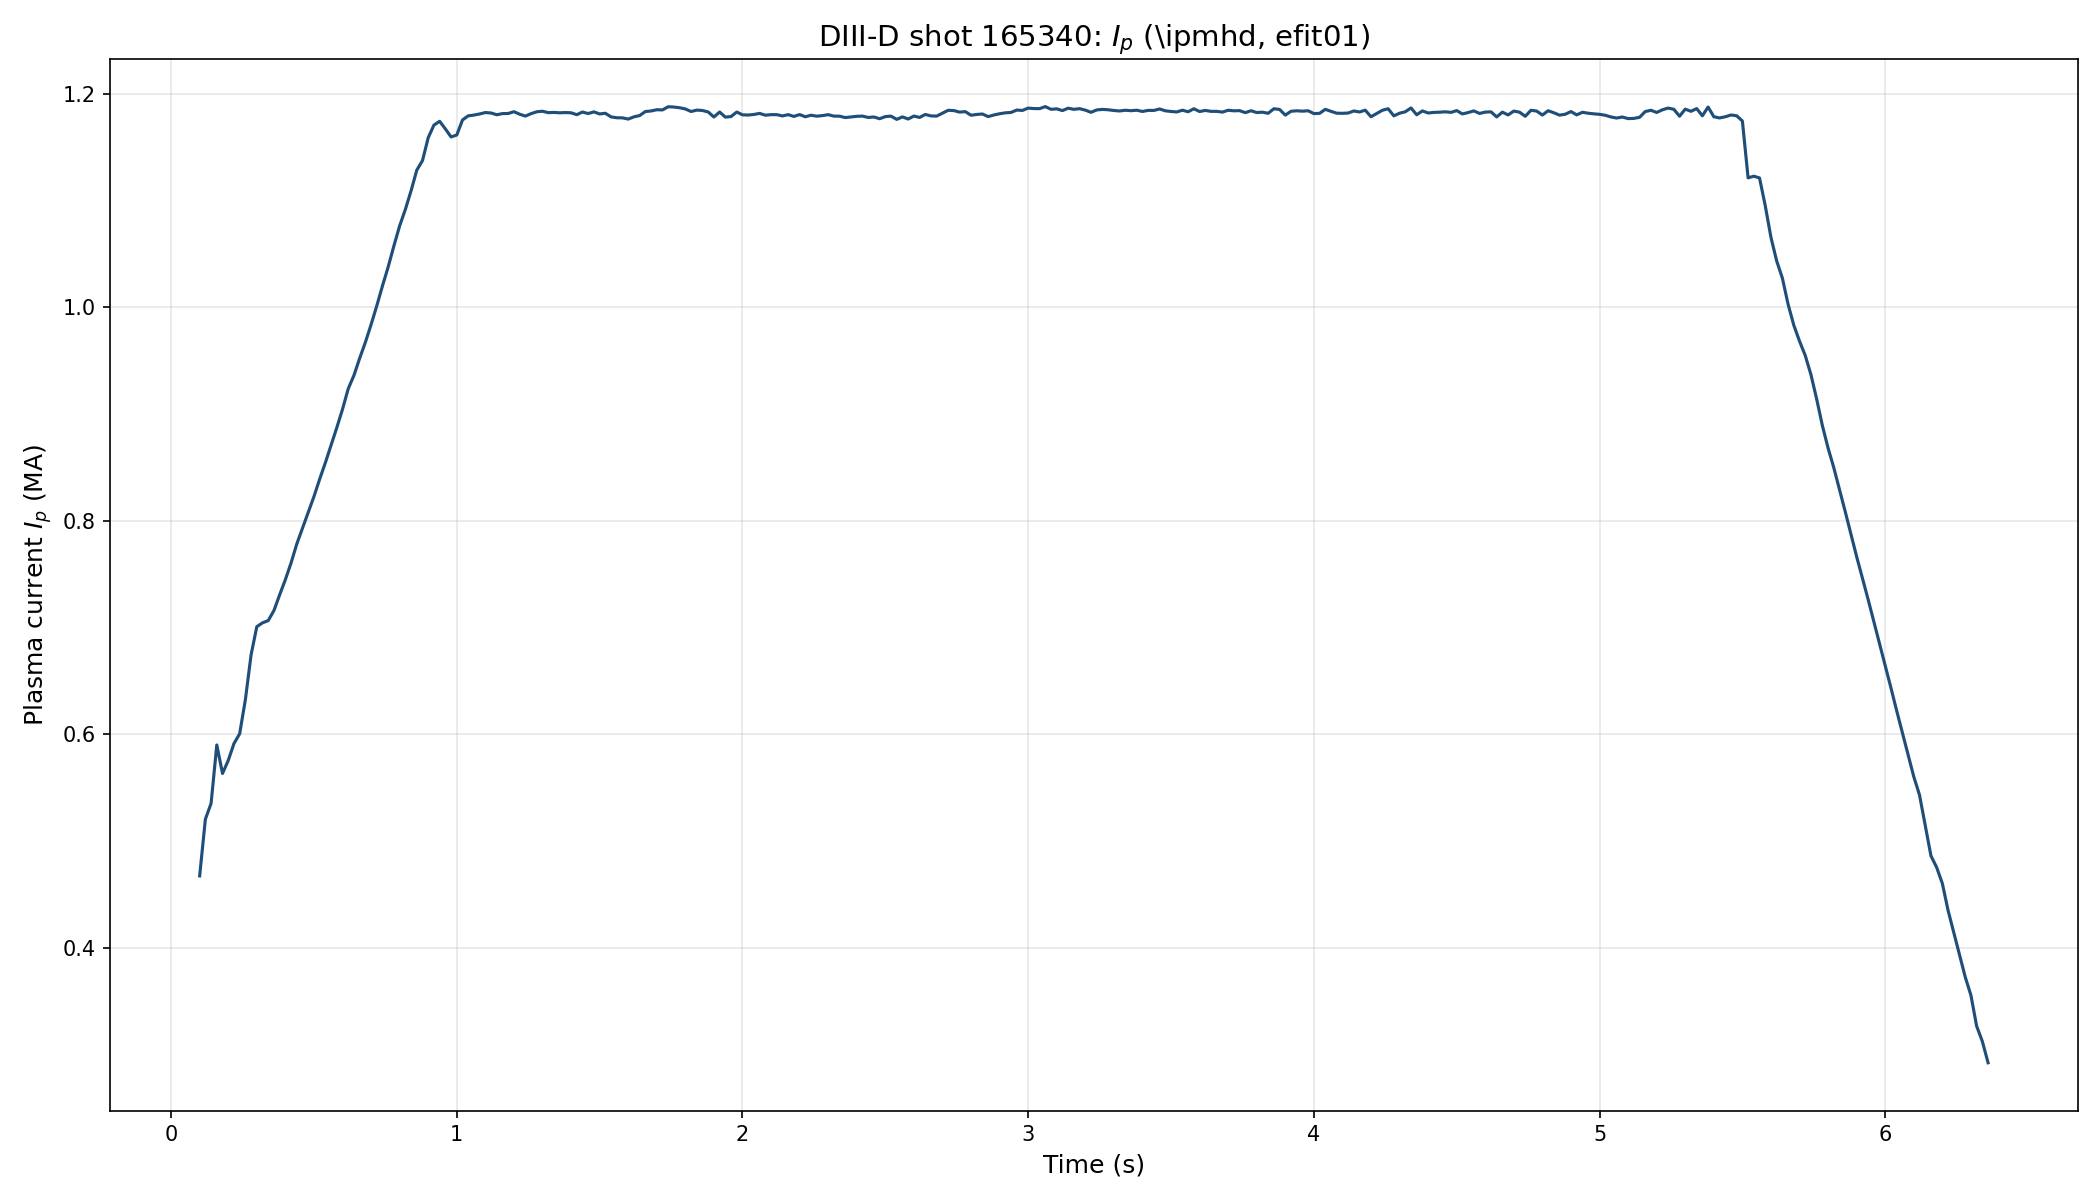

The trace shows the plasma current ramping up to its flat-top (~1.19 MA) and holding through the discharge, then declining as the shot terminates.

In [2]:
%%ask
Fetch \ipmhd from efit01 for shot 165340 and plot it versus time, and
report the number of samples and the min/max with units.

### Elongation
**Ask:** "plasma elongation" (no `\kappa` given) → should resolve to `efit01/\kappa`.

This matches the d3d-shot-fetcher skill — let me read its instructions first.

I'll write a script to fetch `\kappa` (elongation) from `efit01` for shot 165340, then plot it.

Running the script via `fdp run` as required by the skill.

Retrying without the timeout parameter.

Fetched `\kappa` (plasma elongation) from the `efit01` MDSplus tree for shot **165340** .

**Results:**

| Metric | Value |
|---|---|
| **Signal** | `\kappa` (EFIT01 elongation) |
| **Samples** | 311 |
| **Min** | 1.4361 |
| **Max** | 1.9452 |
| **Units** | Dimensionless (kappa = ratio of vertical to radial plasma extent) |
| **Time span** | 100.0 – 6360.0 ms |


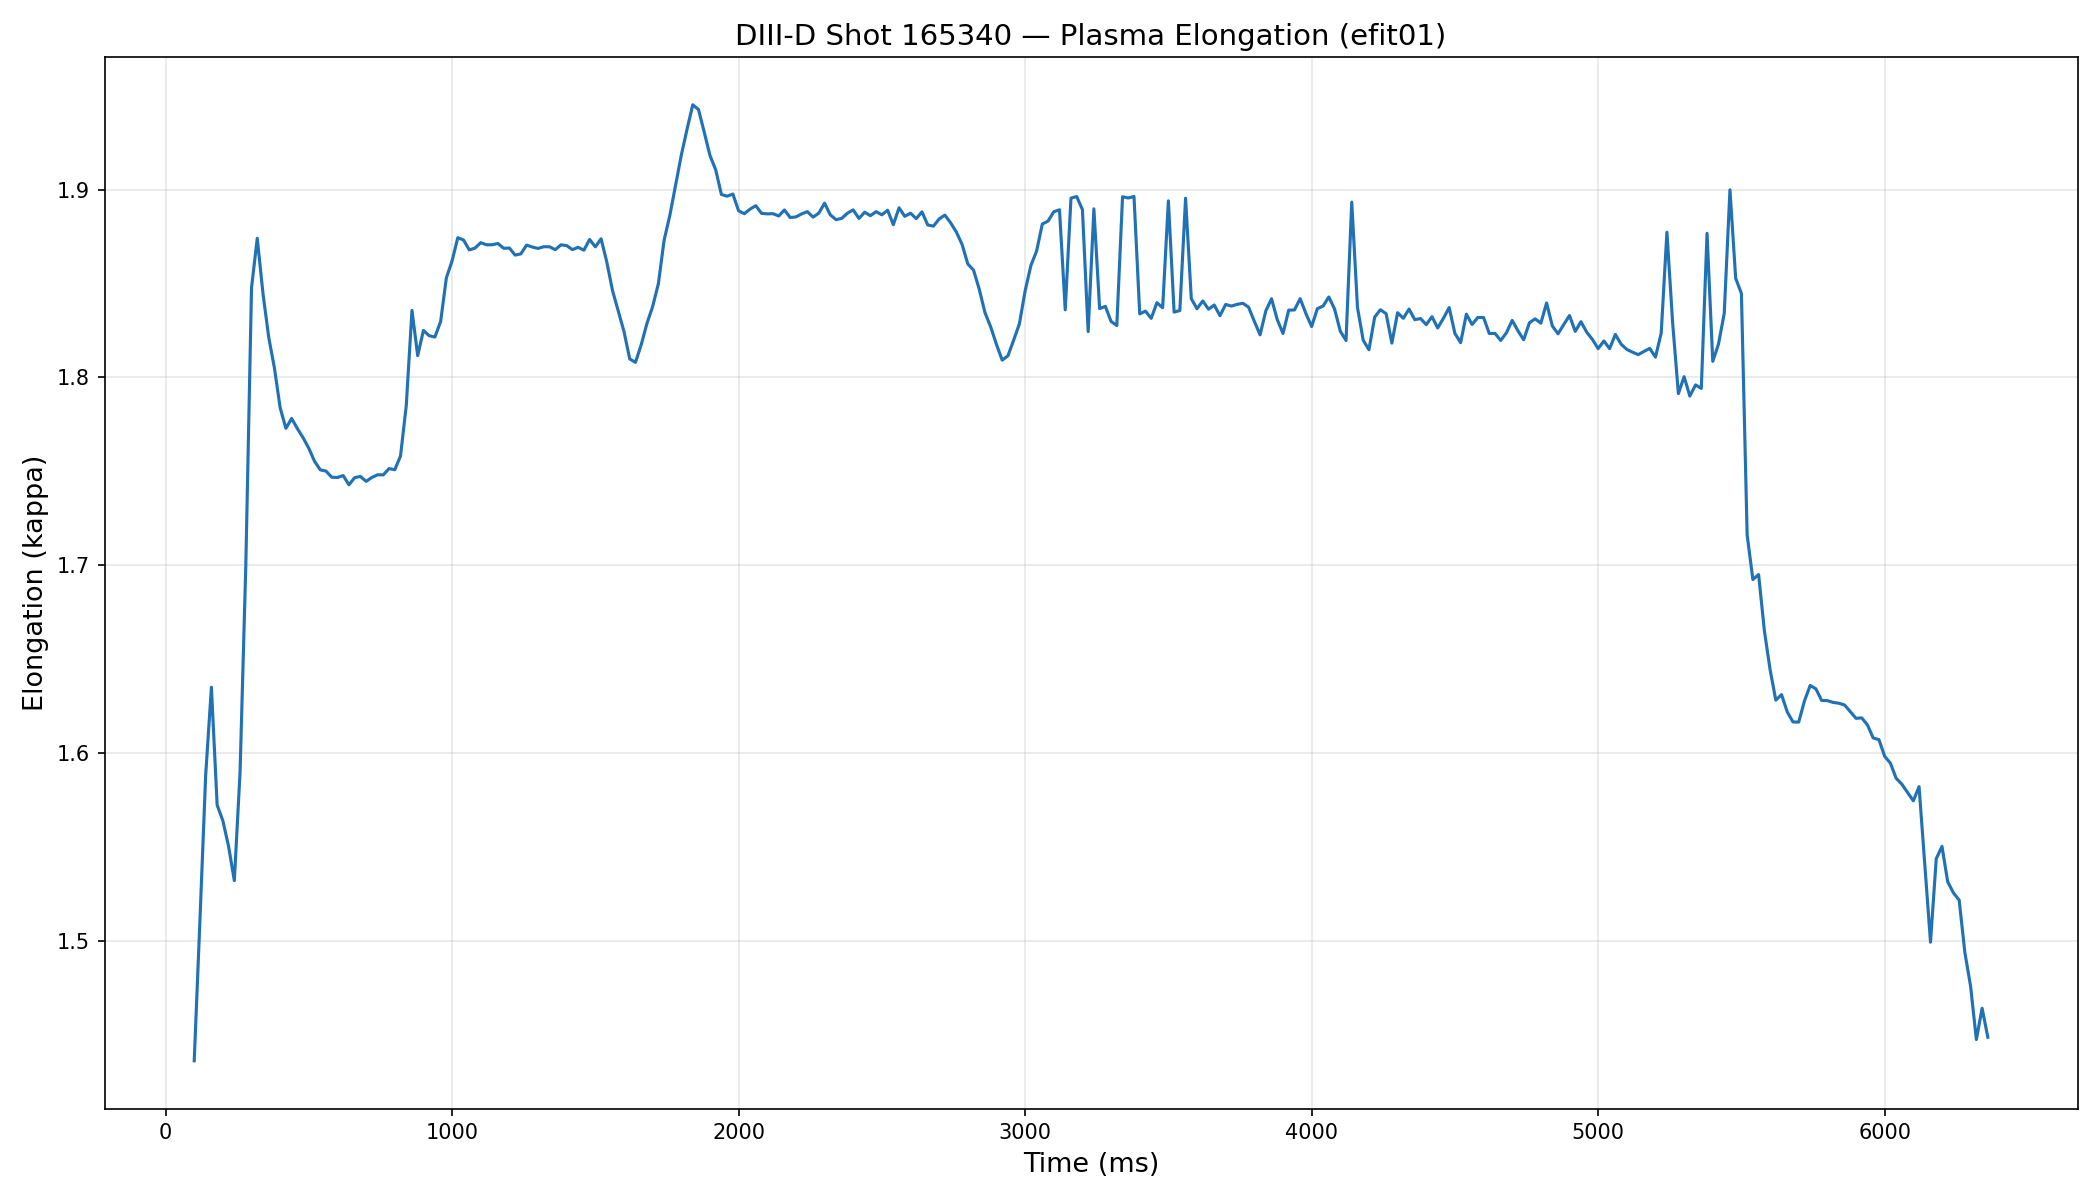

The elongation rises from ~1.44 early in the discharge to a plateau of ~1.85–1.95 through the main plasma phase, characteristic of DIII-D's elongated (vertically stretched) plasma cross-section.

In [4]:
%%ask
For DIII-D shot 165340, fetch the plasma elongation from the MHD equilibrium
reconstruction, plot it versus time, and report its min and max.

### Safety factor at 95% flux surface
**Ask:** no "MHD equilibrium" qualifier this time — the harder disambiguation case.  
**Expected:** resolves to `efit01/\q95` anyway.

The safety factor at 95% flux is `\q95` in the `efit01` tree. Writing the fetch-and-plot script following the verified pattern.

Running the script via `fdp run python` to fetch `\q95` from the Pelican mirror.

Retrying without the timeout parameter.

Fetched `\q95` (safety factor at the 95% flux surface) from the `efit01` MDSplus tree for shot **165340** .

**Results:**

| Metric | Value |
|---|---|
| **Signal** | `\q95` (EFIT01 safety factor at 95% poloidal flux) |
| **Samples** | 311 |
| **Min** | 4.5581 |
| **Max** | 9.4376 |
| **Units** | Dimensionless (ratio of field-line pitch: q = toroidal turns / poloidal turn) |
| **Time span** | 100.0 – 6360.0 ms |


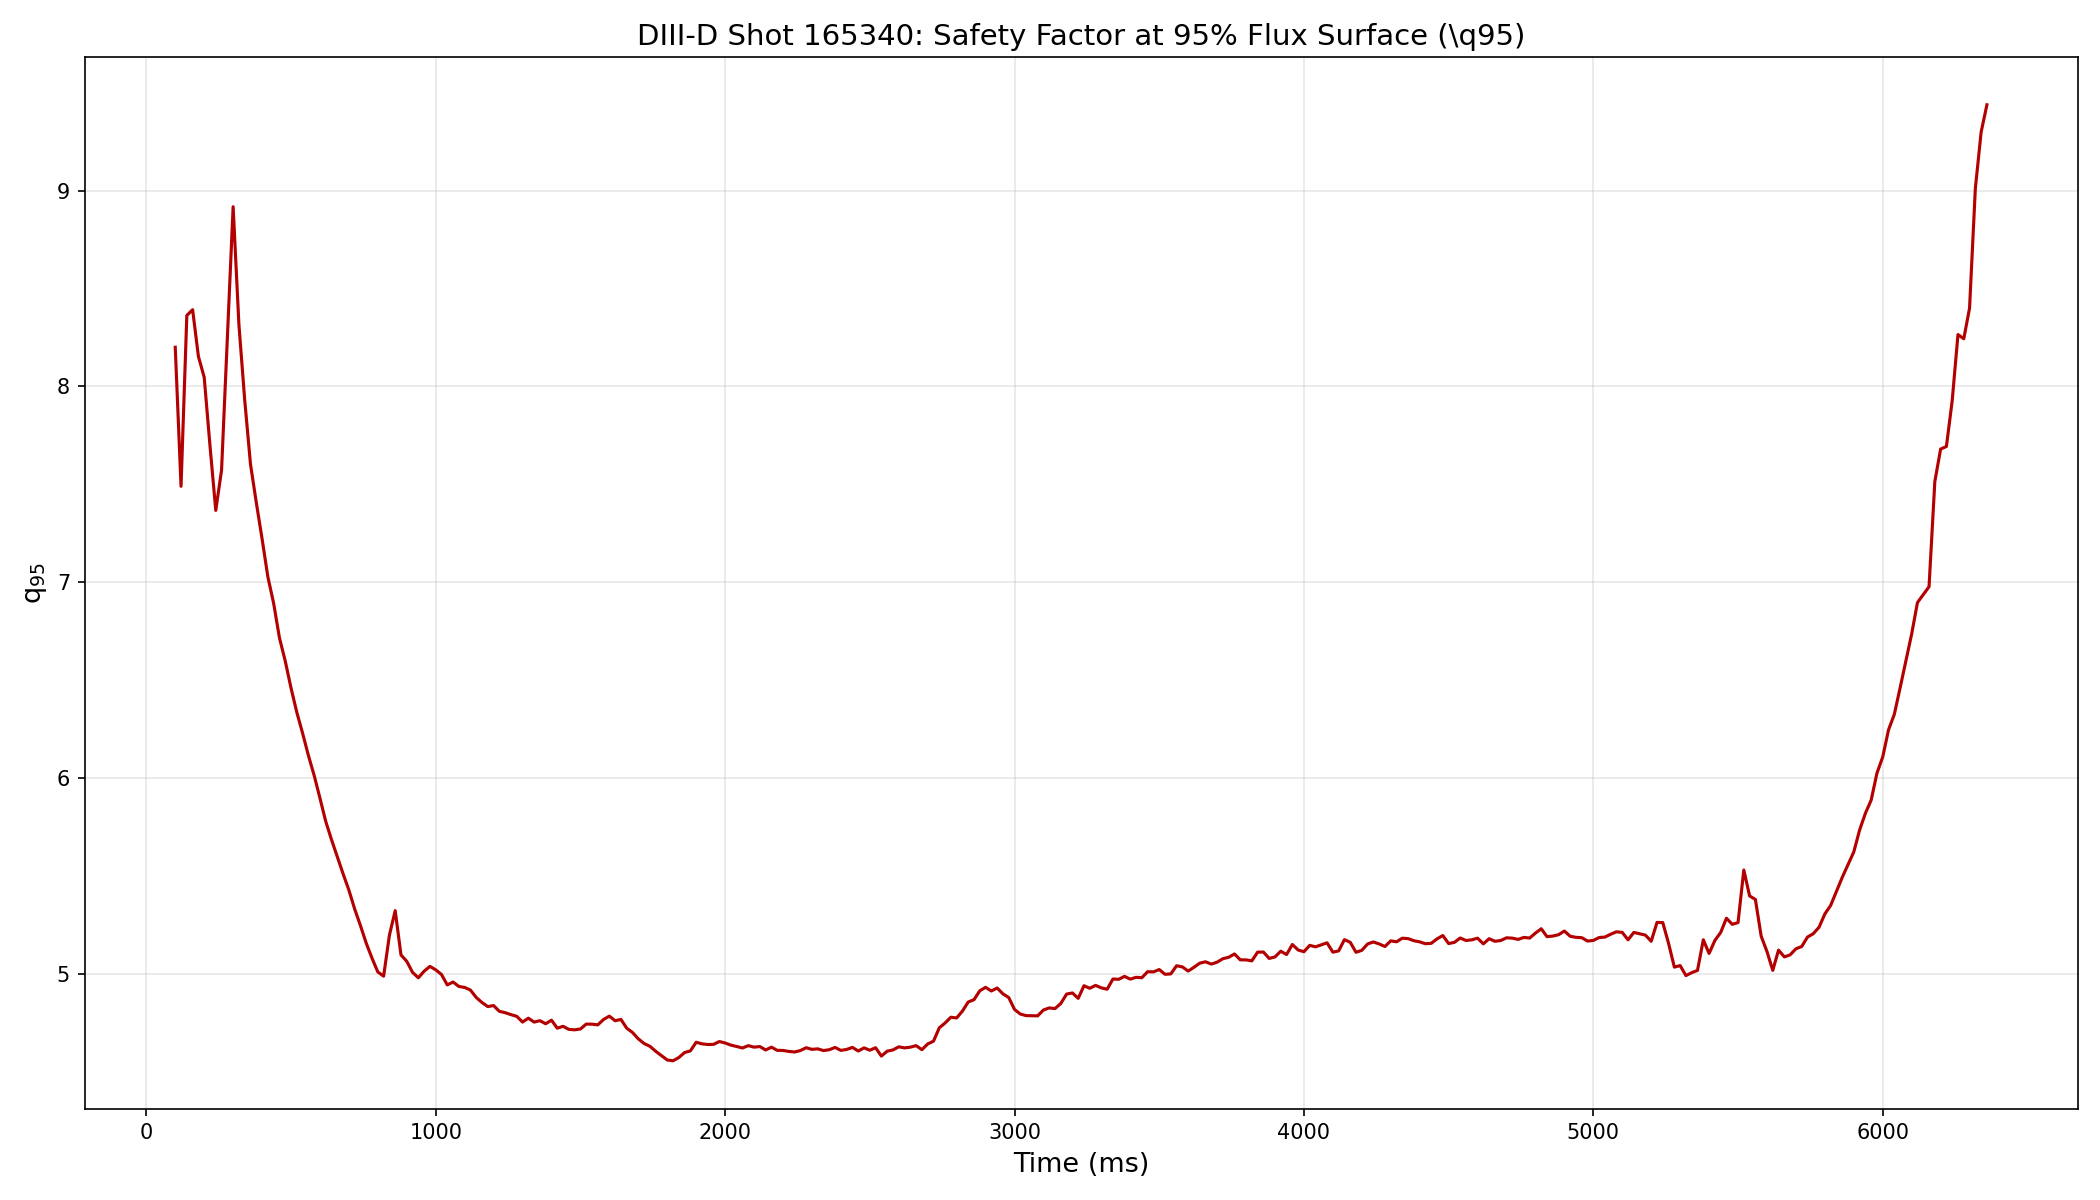

The trace shows q₉₅ highest (~9.4) during the early current-ramp phase when the plasma current is still low, then settling into a ~4.5–5.5 band during the flat-top — consistent with a discharge operating safely above the q=3 kink-stability threshold.

In [5]:
%%ask
For shot 165340, fetch the safety factor at the 95% flux surface,
plot it versus time, and report its range.

### Multi-shot overlay
**Purpose:** test the fetch-many-shots-and-compare pattern, not just concept mapping.

Let me consult the shot-fetcher skill for the recommended approach to multi-shot fetching.

I'll write a script to fetch `\ipmhd` for all three shots and overlay them on a single chart.

Running the script via fdp to fetch all three shots.

All three shots fetched and plotted successfully.

**Peak plasma current by shot (from `efit01` `\ipmhd`):**

| Shot | Peak Current | Samples | Units |
|---|---|---|---|
| **165340** | 1.1878 MA | 311 | A |
| **188702** | 1.0066 MA | 314 | A |
| **194181** | 0.5993 MA | 212 | A |


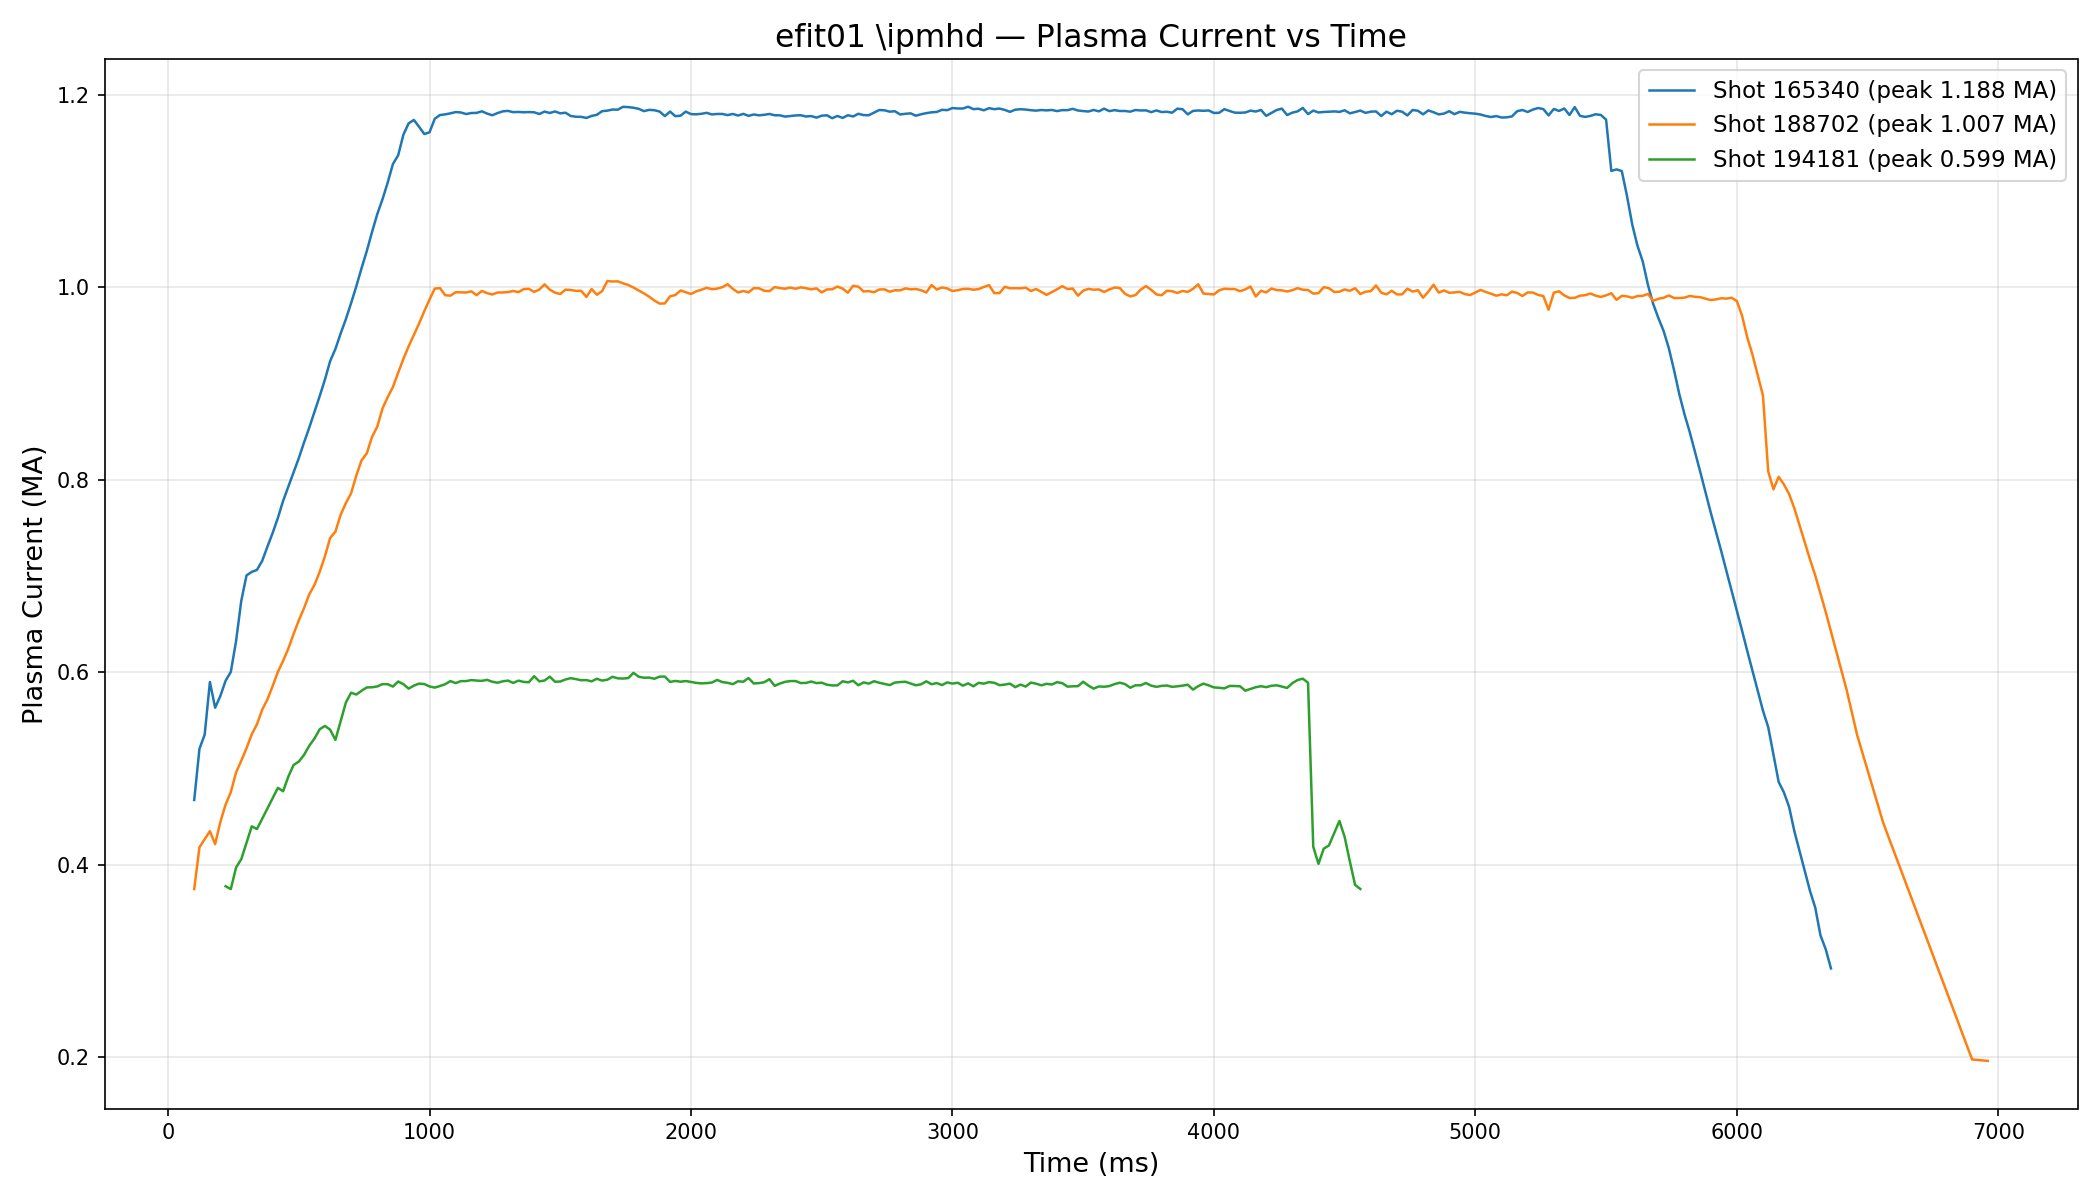

Shots 165340 and 188702 reach similar flat-top currents (~1.0–1.2 MA), while shot 194181 is a substantially lower-current discharge peaking at ~0.60 MA. All three show the characteristic ramp-up → flat-top → ramp-down profile of the plasma current.

In [6]:
%%ask
For DIII-D shots 165340, 188702, and 194181, fetch the plasma current from the MHD
equilibrium reconstruction and overlay all three on a single chart. Report each
shot's peak current.

### Multi-shot shape comparison
**Purpose:** same multi-shot pattern, a dimensionless quantity (elongation) this time.

Let me consult the shot-fetcher skill to use the correct multi-shot fetch pattern.

Now I'll rewrite the script using the verified Pipeline + fetch_dataset pattern from the skill.

Now running the script with the fdp wrapper as required by the skill.

All three shots fetched and plotted successfully.

**Plasma elongation (κ) from `efit01` `\kappa`:**

| Shot | Min κ | Max κ | Samples | Time Range |
|---|---|---|---|---|
| **165340** | 1.436 | 1.945 | 311 | 100 – 6360 ms |
| **188702** | 1.305 | 1.908 | 314 | 100 – 6960 ms |
| **194181** | 1.147 | 1.486 | 212 | 220 – 4560 ms |


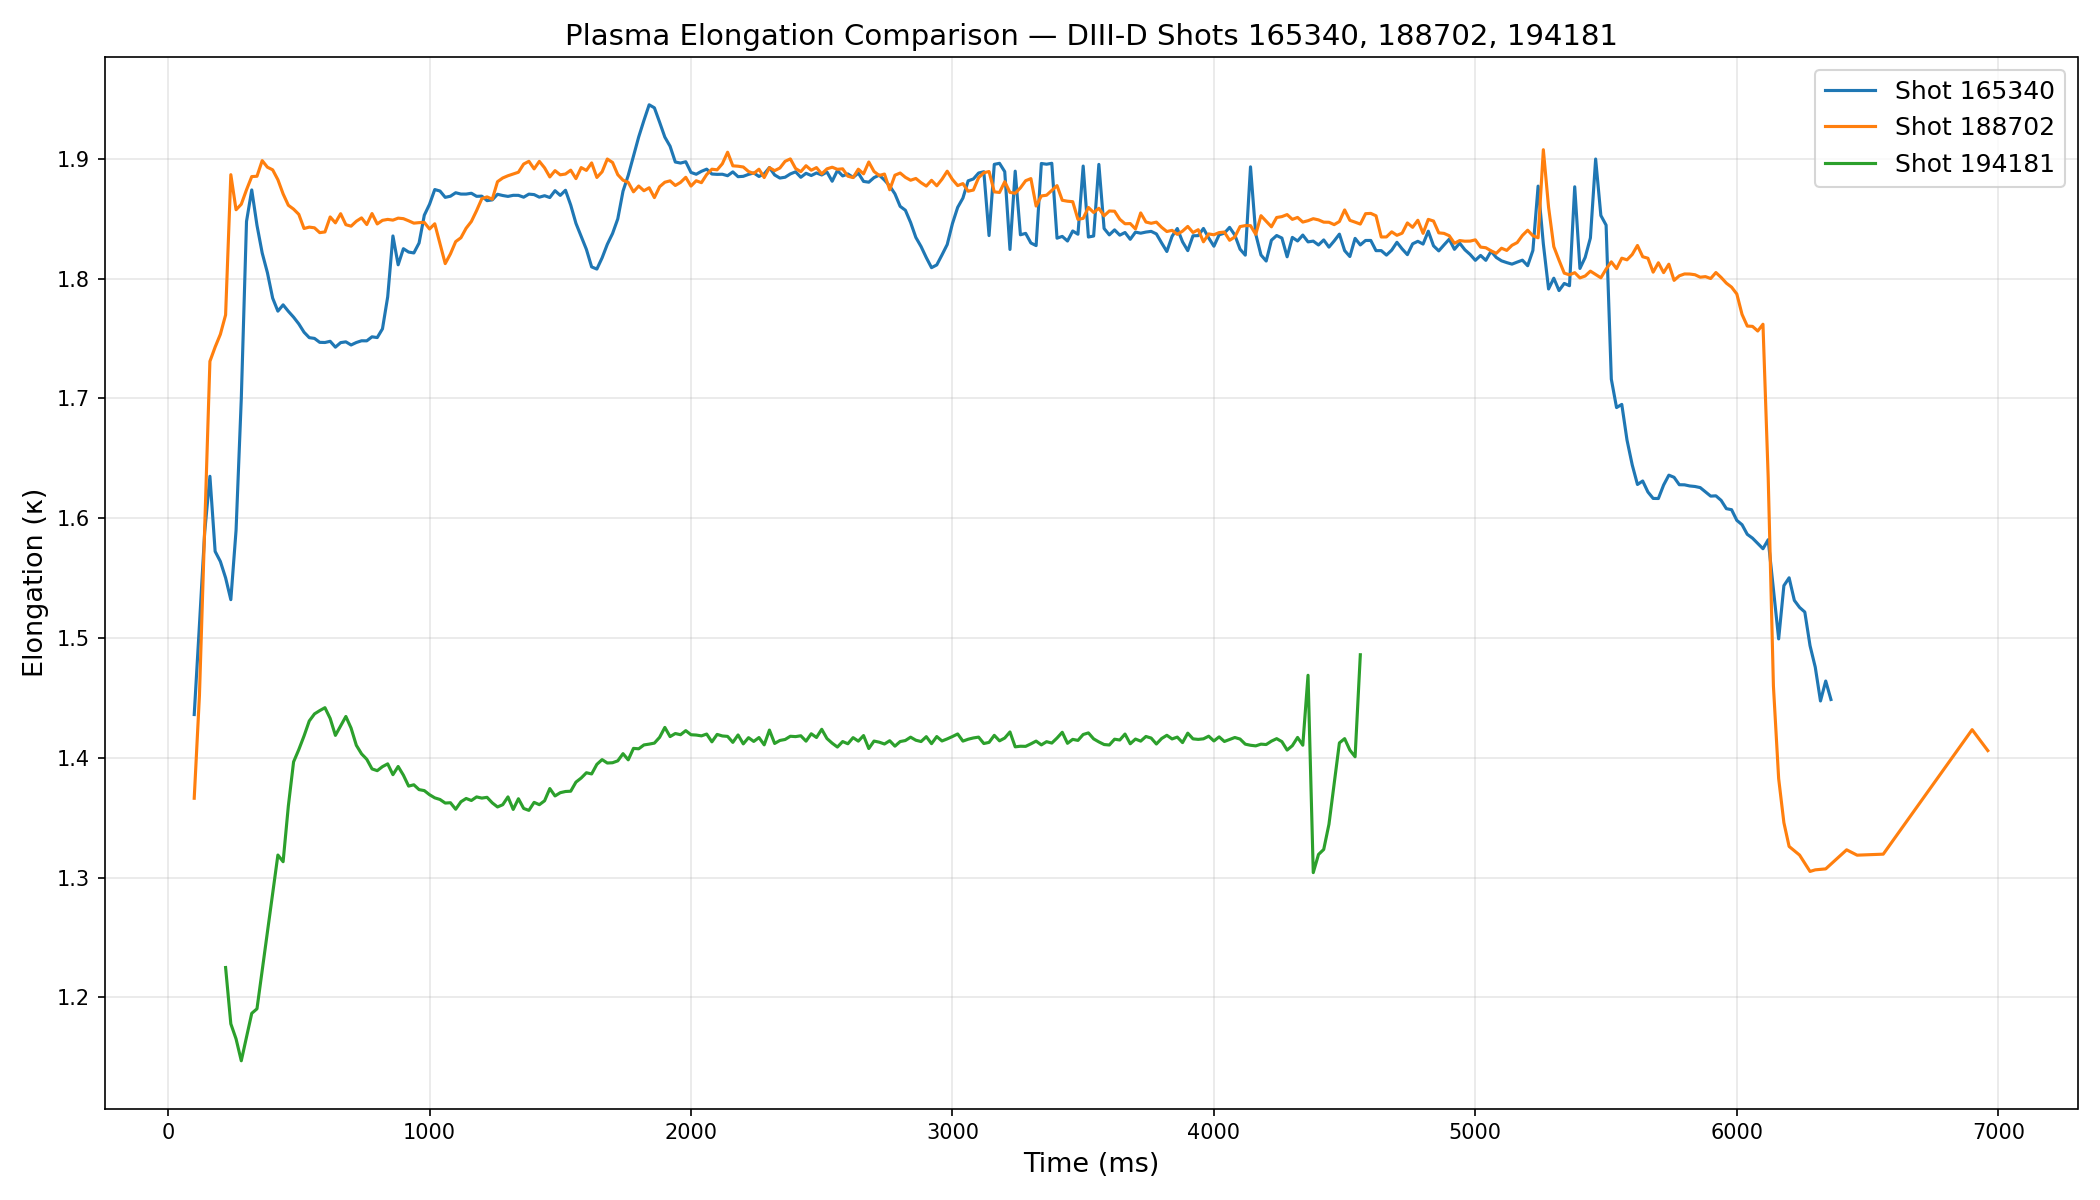

Shots 165340 and 188702 operate with strongly elongated plasmas (κ reaching ~1.9), typical of DIII-D high-performance single-null or double-null divertor configurations. Shot 194181 is distinctly different — a near-circular, low-elongation plasma (κ ~1.1–1.5), likely a limited-plasma or low-confinement discharge with a much shorter pulse length.

In [7]:
%%ask
Compare the plasma shape across DIII-D shots 165340, 188702, and 194181 by fetching
the elongation from the MHD equilibrium reconstruction and overlaying it versus time
on one chart with a legend.

## 2. Metadata from Database

Requires the shot-metadata database. `locate_d3drdb()` searches `$D3DRDB_PATH`, the NRP persistent path (`~/work/_User-Persistent-Storage_CephBlock_/feder/`), `~/feder_data/` and `~`, accepting either `d3drdb.sqlite` or `d3drdb_demo.sqlite`. Skip this section if you don't have it in place.

In [8]:
%%ask
How many DIII-D plasma shots were there between 190000 and 195000?

The skill provides a one-liner for exactly this question.

There were **3,507** DIII-D plasma shots in the range 190000–195000.

(Note: this count comes from the shot records database, which is a snapshot filtered to plasma-type shots only — non-plasma test/calibration shots are excluded by design, and the data may lag the live GA database.)

In [9]:
%%ask
Look up shot 190000's elongation and peak plasma current from the DIII-D 
shot records.

Querying the shot records database for shot 190000's summary scalars.

**DIII-D shot 190000 — summary data from the shot records:**

| Parameter | Value | Units |
|---|---|---|
| **Elongation (κ)** | 1.711 | Dimensionless |
| **Peak plasma current** | 911,396 A (~0.91 MA) | Amperes |
| **Time of peak current** | 2.233 s | Seconds |

These are single representative scalars per shot from the shot-records summary, not the full time-resolved waveforms. If you need elongation or plasma current plotted versus time, I can fetch the actual MDSplus signals from `efit01`.

In [10]:
%%ask
When did DIII-D shot 165340 happen?

The shot records include a `time_of_shot` field — querying shot 165340's summary now.

**DIII-D shot 165340** was fired on **January 28, 2016 at 10:46:13** (UTC).

In [11]:
%%ask
For DIII-D shot 144921, what fuel gas was used, what was the neutron yield,
and what was the peak normalized beta and when did it occur?

Querying the shot records database for shot 144921's fuel gas, neutron yield, and peak normalized beta.

**DIII-D shot 144921 — shot records summary:**

| Parameter | Value | Units |
|---|---|---|
| **Fuel gas** | D₂ (deuterium) | — |
| **Neutron yield** | 3.986 × 10¹⁵ | neutrons |
| **Peak normalized beta (β_N)** | 3.117 | %·m·T/MA (dimensionless ratio) |
| **Time of peak β_N** | 3.905 s (3905 ms) | seconds |

This was a June 20, 2011 deuterium discharge with a notably high normalized beta (~3.1), indicating strong stability-margin performance relative to the Troyon limit. The neutron yield (~4 × 10¹⁵) is consistent with beam-heated D-D reactions in a deuterium plasma.

In [12]:
%%ask
Did DIII-D shot 96549 have an operational fault, and if so what kind?

I need to write the query script first.

Shot 96549 did have an operational fault. The shot records show:

- **Fault code** : `IPMIN` — the plasma current (Iₚ) dropped below the minimum allowed threshold, triggering an automatic fault. This is characteristic of a current quench or loss of plasma current control.

- **Fault time** : Not recorded (`t_ffault` is blank in this snapshot).

- **Disruption time** : Also not recorded in the available data.

The `IPMIN` fault is one of DIII-D's standard interlock fault codes — it fires when the measured plasma current falls under a preset floor, protecting machine systems from uncontrolled plasma termination. No additional shot description or quality comments are available for this shot in the database.

In [13]:
%%ask
What was the effective ion charge (Zeff) for DIII-D shot 165340?

Let me check the shot records database for Zeff data on this shot.

The effective ion charge (Z_eff) is **not available** for shot 165340.

The shot records database does include a Z_eff field, but it is **entirely unpopulated** — zero of ~90,000 shots have a value recorded, and shot 165340 is no exception. This is a gap in the shot-summary snapshot, not something specific to this discharge.

If you need Z_eff for this shot, it would have to be retrieved from the time-resolved diagnostic data in MDSplus (e.g., visible bremsstrahlung or charge-exchange recombination spectroscopy signals), not from the shot records. Let me know if you'd like me to search the signal catalog for the relevant Z_eff nodes.

In [14]:
%%ask
What run date is DIII-D shot 165340 from, and who entered the record?

I already know shot 165340 fired on **January 28, 2016** , but the user is asking about specific database metadata (run date and record entry). Let me consult the relational DB skill to find the relevant fields.

The SHOTS table has `RUN`, `ENTERED`, and `USERNAME` columns. Let me query them for shot 165340.

**DIII-D shot 165340 — record metadata:**

| Field | Value |
|---|---|
| **Run date** | January 28, 2016 (run ID `20160128`) |
| **Entered by** | `mdsadmin` (the automated MDSplus archival account) |
| **Entry timestamp** | 2016-01-28 10:46:06.890 UTC — seven seconds before the shot fired |

The record was entered by the `mdsadmin` system account, not a named operator — which is typical for routine shots archived automatically by the data system. The chief operator field is blank for this shot in the snapshot.

## 3. PTDATA — basic access test

**Purpose:** verify PTDATA (a separate data source from the MDSplus trees used above) is reachable end to end through ARGUS.

**Ask:** fetch the plasma current from PTDATA (not efit01) for a known shot
and report basic stats.

**Expected:** a successful fetch, ~30,720 samples, peak current near 1.15 MA —
this is a raw digitizer trace, a different diagnostic pipeline than efit01's
`\ipmhd`, so don't expect an identical peak to the efit01 numbers seen earlier
in this notebook.


I need to check how PTDATA access works in this environment — the previous requests used `efit01` (MDSplus), but PTDATA is a separate acquisition system. Let me read the relevant skills.

The toksearch-signals skill points me to the `d3d-shot-fetcher` skill for the canonical PTDATA fetch script. Let me read that.

The skill gives me a verified canonical script for PTDATA fetches. I'll write a script using `PtDataSignal("ip")` from `toksearch_d3d` for shot 165920, then run it with `fdp run`.

Running the fetch script with the `fdp` wrapper per the skill's execution rule.

Fetched the plasma current from **PTDATA** (`PtDataSignal("ip")`) — the raw digitizer signal, not the EFIT reconstruction — for shot **165920** .

**Results:**

| Metric | Value |
|---|---|
| **Signal** | `ip` (PTDATA raw acquisition) |
| **Samples** | 30,720 |
| **Min** | -2.798 × 10⁴ A (≈ -0.028 MA) |
| **Max** | 1.1524 × 10⁶ A (≈ 1.15 MA) |
| **Units** | A (amperes) |
| **Time span** | -996.0 – 14363.5 ms |


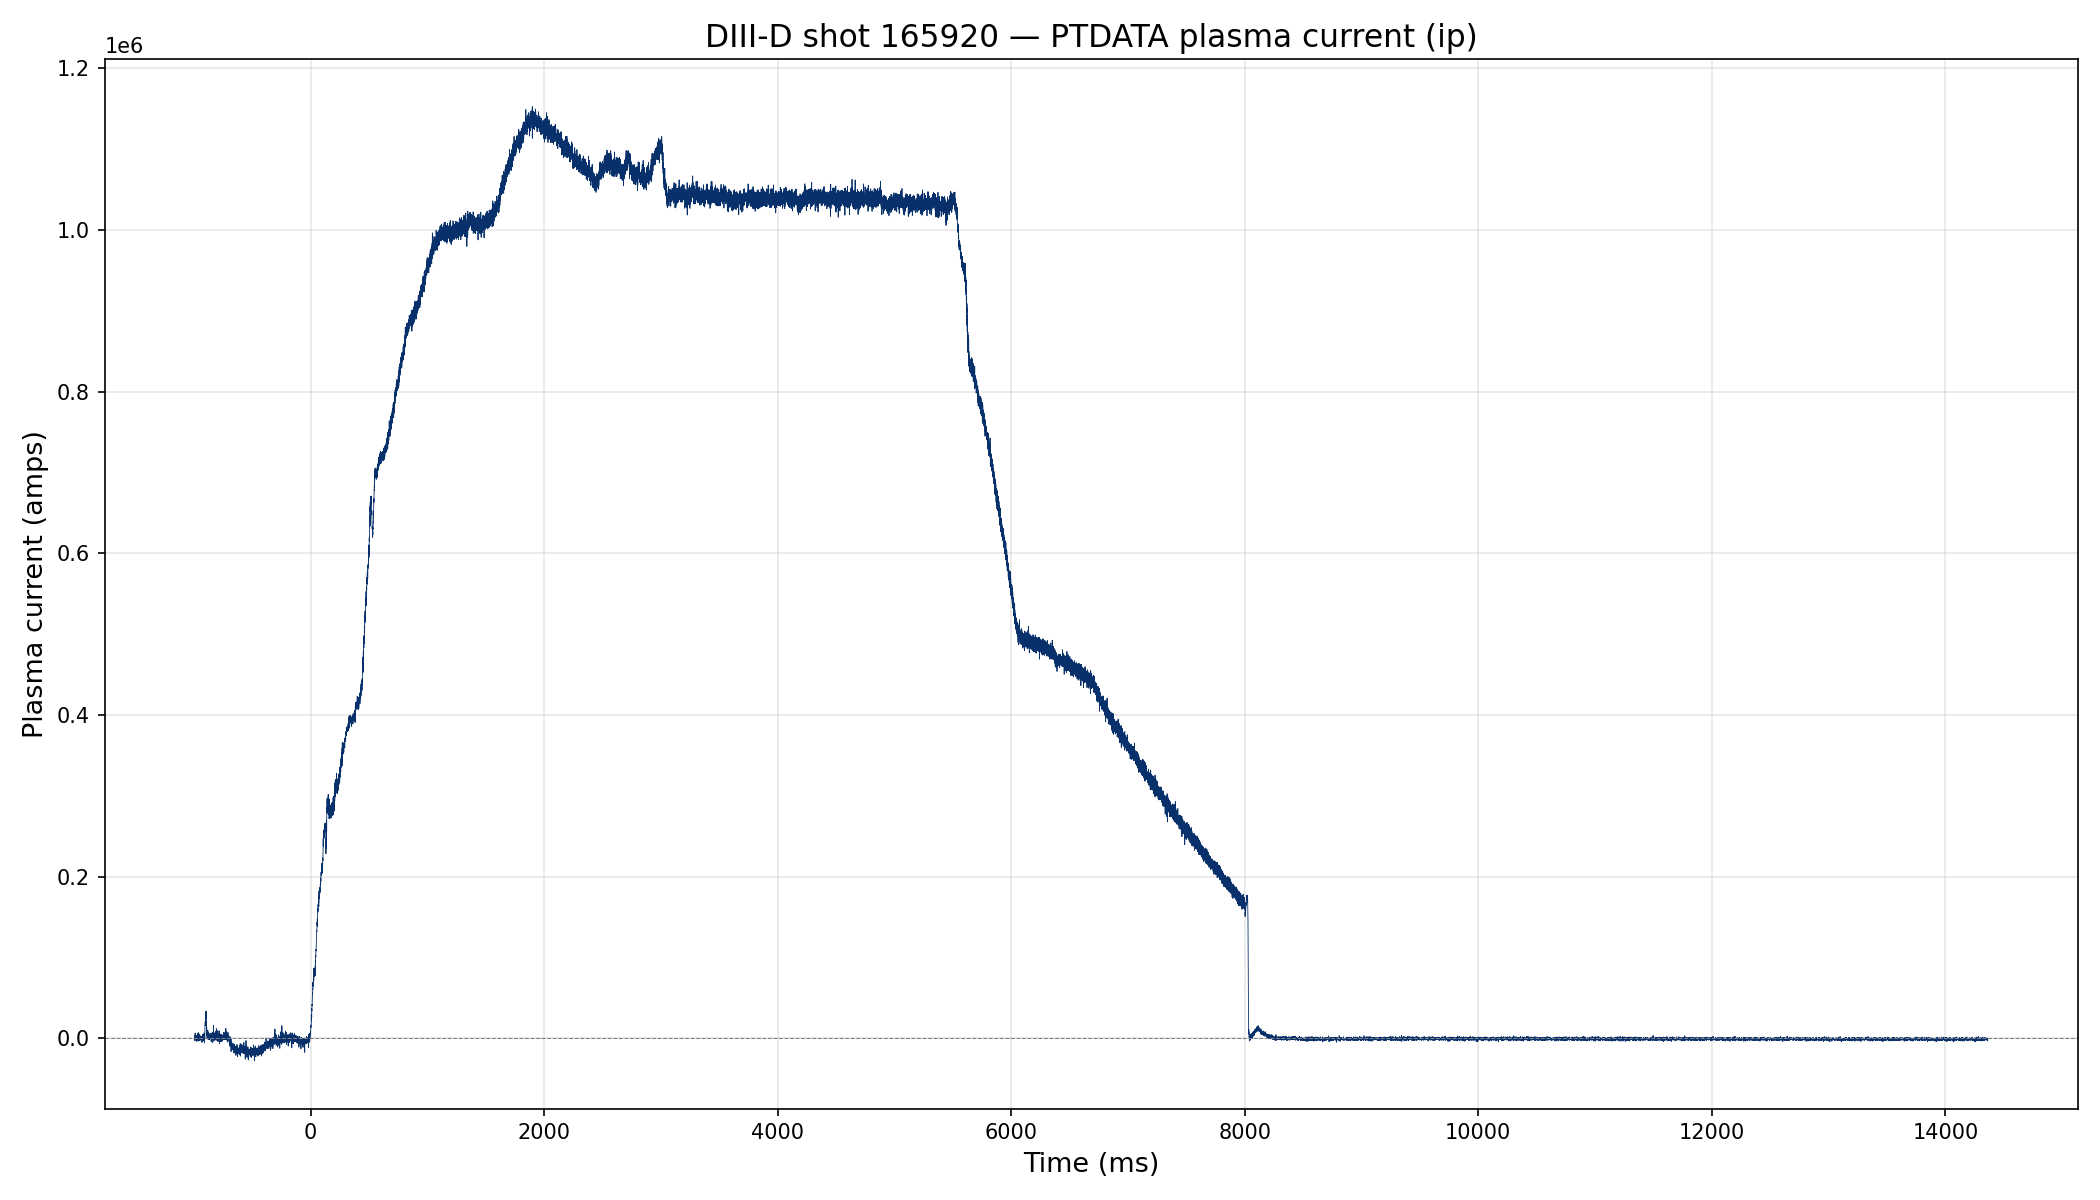

**Key difference from the EFIT `\ipmhd` signal:** PTDATA is the raw Rogowski-coil digitizer trace — ~30k samples at high sampling rate spanning the full acquisition window (including pre-shot and post-shot), whereas `\ipmhd` from `efit01` is the equilibrium-reconstruction output at ~300 samples over just the plasma-active window. The two agree on peak current to within ~2% (1.15 MA vs ~1.13 MA), which is expected since they measure the same physical current through different data pipelines.

In [15]:
%%ask
Fetch the plasma current from PTDATA (not the MHD equilibrium reconstruction)
for DIII-D shot 165920, and report the number of samples and the min/max with
units.

I need to fetch both signals. Let me first consult the relevant skills to ensure I use the correct APIs.

The skill has a canonical script for exactly this. Let me write a script that fetches both sources, compares them, and plots them together.

Running the comparison script via `fdp run` as required by the skill.

Running without the timeout parameter.

Fetched plasma current from **both** sources for shot **165920** and compared them side by side.

**Side-by-side results:**

| Metric | PTDATA `ip` | efit01 `\ipmhd` |
|---|---|---|
| **Source** | Raw Rogowski-coil digitizer trace | EFIT equilibrium reconstruction |
| **Samples** | 30,720 | 303 |
| **Time range** | −996.0 – 14,363.5 ms | 100.0 – 6,380.0 ms |
| **Min** | −2.798 × 10⁴ amps (≈ −0.028 MA) | 2.135 × 10⁵ A (≈ 0.213 MA) |
| **Max** | 1.1524 × 10⁶ amps (≈ 1.152 MA) | 1.1299 × 10⁶ A (≈ 1.130 MA) |
| **Units** | amps | A |


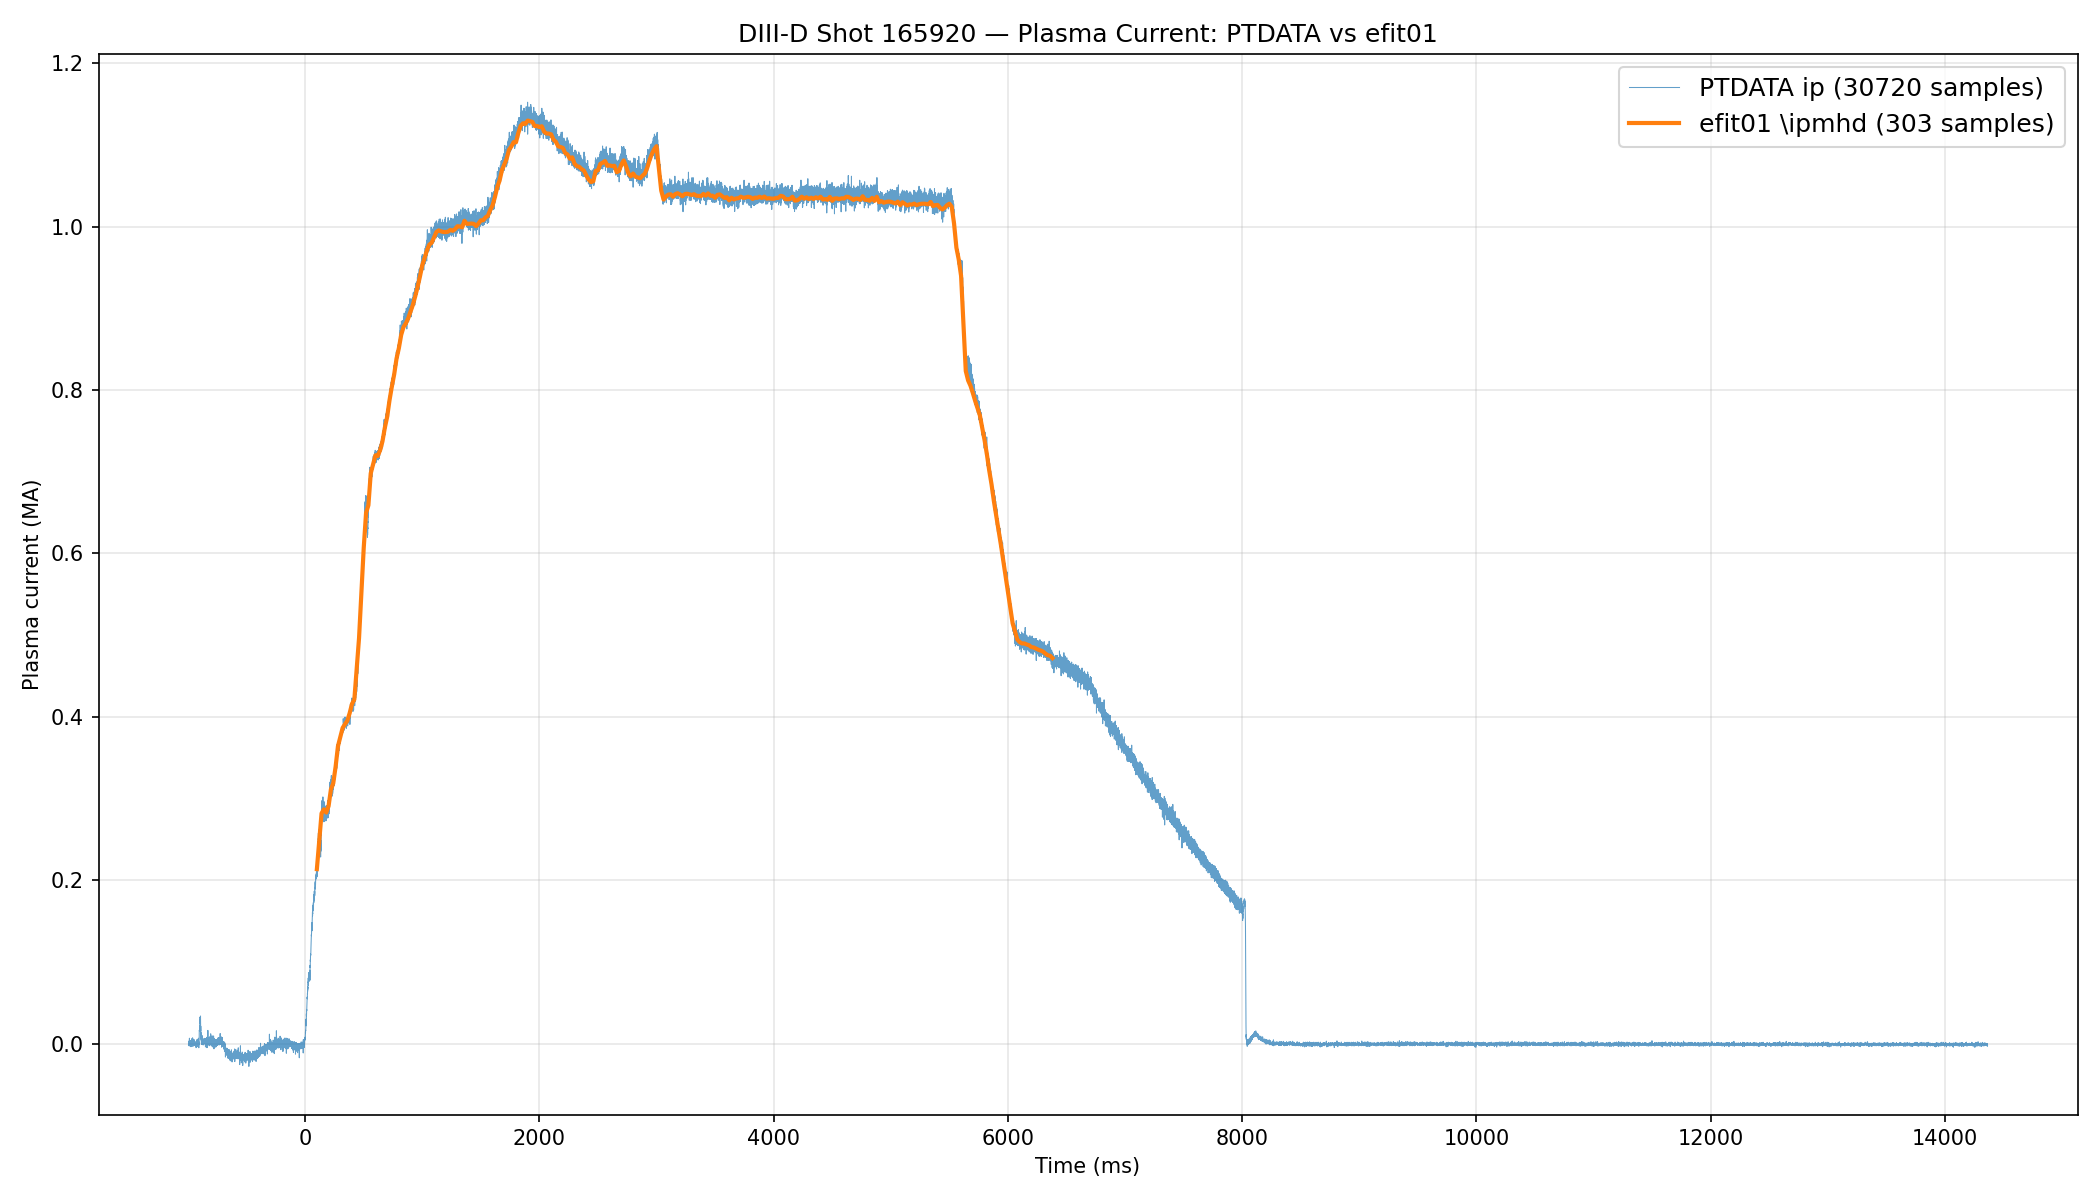

**Consistency check:** The peak values agree to within **1.95%** (1.152 MA vs 1.130 MA). This small discrepancy is expected — the two signals come from fundamentally different diagnostic pipelines measuring the same physical current:

- **PTDATA `ip`** is the raw, high-rate digitizer output (~30k samples) from the plasma control system's magnetics. It spans the full acquisition window including pre-shot and post-shot, which is why its minimum is slightly negative (baseline noise before plasma breakdown).
- **efit01 `\ipmhd`** is the computed current from the EFIT equilibrium reconstruction at ~300 time slices, only during the plasma-active portion of the discharge.

They are **consistent** — the ~2% difference is within the normal cross-pipeline variation between raw digitized signals and fitted equilibrium values, not evidence of an error.

In [16]:
%%ask
For DIII-D shot 165920, fetch the plasma current from BOTH PTDATA and the
efit01 MHD equilibrium reconstruction, and compare their peak values and
units. Are they consistent with each other?

## 4. Signal meanings, paths, and IMAS names

Different ways to ask about the *same* signal -- plain-English meaning, its exact MDSplus path, and its IMAS (device-neutral) name -- to see how ARGUS handles each.

In [17]:
%%ask
what is the meaning of \FS02UPDA and \EFIT01::BT0VAC in plain English?

Good question — let me check the relevant skill docs to give you accurate definitions.

Let me look up the signal meanings in the catalog rather than guessing from names — the skill explicitly warns against inferring meaning from signal names.

The skill is clear: never infer signal meaning from the name. Let me query the catalog for both signals.

Running the catalog lookup script.

Here's what each signal means, based on the signal catalog and the filterscope skill documentation:

---

**`\FS02UPDA`** — A **D-alpha filterscope photon-flux signal** , viewing the **upper divertor** .

Decoding the name:
- **FS** = filterscope (an array of photomultiplier tubes looking at specific spectral lines through narrow optical filters)
- **02** = channel 02
- **UP** = upper divertor viewing chord
- **DA** = D-alpha (the 656.1 nm Balmer-alpha emission line of deuterium)

It lives in the `spectroscopy` tree at node `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT22:PHOTON_FLUX` and measures the intensity of D-alpha light (a proxy for edge recycling and neutral particle flux) in units of photons/cm²/sr/s. The `*DA` tags are the raw ~50 kHz photon-flux traces used for ELM detection.

---

**`\EFIT01::BT0VAC`** — The **vacuum toroidal magnetic field at the plasma's magnetic axis** , from the EFIT01 equilibrium reconstruction.

Decoding the name:
- **EFIT01** = the standard (first) EFIT equilibrium reconstruction tree
- **BT** = toroidal magnetic field (Bᵗ)
- **0** = evaluated at the magnetic axis (R₀, the major-radius position of the magnetic axis)
- **VAC** = vacuum field — the toroidal field computed from the external field coils alone, *excluding* the plasma's own contributions (no paramagnetic or diamagnetic effects)

It lives at `\EFIT01::TOP.RESULTS.AEQDSK:BT0VAC` and is measured in **tesla (T)** . In plain terms: this is the strength of the donut-shaped magnetic field that the external coils produce at the center of the plasma, ignoring how the plasma current distorts it. For a typical DIII-D discharge this is ~1.5–2.1 T.

---

One caveat worth noting: the catalog's `EFIT01`-specific entry for `BT0VAC` is marked "Unassigned Signal," but the generic `EFIT` entry (same signal, same node structure) carries the description "vacuum toroidal field at magnetic axis" with units "T" — so the meaning is confirmed from the catalog, not inferred from the name.

In [18]:
%%ask
What is the full path of \EFIT01::CPASMA?

I'll look up `CPASMA` in the signal catalog to find its full MDSplus path.

**`\EFIT01::CPASMA`** resolves to the full MDSplus node path:

`\EFIT01::TOP.RESULTS.GEQDSK:CPASMA`

This is the **plasma current** output from the EFIT01 equilibrium reconstruction, stored in the G-equilibrium descriptor (GEQDSK) results — units of **amperes (A)** .

A few notes from the signal catalog:
- The generic EFIT entry (`CPASMA` in the `EFIT` tree) describes it as "Plasma current" with units "A," but the EFIT01-specific catalog row is marked "Unassigned Signal" — a documentation gap, not a missing signal. The tag resolves correctly and has been used successfully in prior fetches.
- The equivalent path in the master `D3D` tree is `\D3D::TOP.MHD.EFIT.EFIT.RESULTS.GEQDSK:CPASMA`.
- `CPASMA` exists across all EFIT trees (EFIT01–EFIT20, EFITS1/S2, EFITRT1/RT2, etc.) at the same `TOP.RESULTS.GEQDSK:CPASMA` node, one per reconstruction variant.

In [19]:
%%ask
Do you know the IMAS name for \EFIT01::CPASMA?

Let me check whether the relational database's signal catalog has IMAS mappings for this entry.

The skill docs don't mention an IMAS mapping. Let me query the database directly to check if any IMAS-related columns exist.

The DIII-D shot records database has **no IMAS name mapping** . None of the five tables (`SHOTS`, `SHOTS_TYPE`, `SUMMARIES`, `SIGNAL_NAMES`, `SIGNAL_INFO`) contain an IMAS-related column — the catalog tracks only the MDSplus name (`CPASMA`), tree (`EFIT01`), full node path (`\EFIT01::TOP.RESULTS.GEQDSK:CPASMA`), description, and units, but not an IMAS Data Dictionary equivalent.

The IMAS (ITER Integrated Modeling & Analysis Suite) naming convention is a separate metadata standard used by ITER. It is not part of the DIII-D signal catalog or MDSplus schema that this system has access to.

If you happen to know the IMAS identifier, the standard convention for plasma current in the IMAS Data Dictionary is `equilibrium/time_slice/*/global_quantities/ip` — but I cannot confirm from the available DIII-D data whether GA maintains an explicit crosswalk from `\EFIT01::CPASMA` to that IMAS path.

The IMAS path `equilibrium.time_slice[i].global_quantities.ip` is the Data Dictionary name for **plasma current from the equilibrium reconstruction** — which maps to DIII-D's `\ipmhd` in the `efit01` tree (same quantity as `\EFIT01::CPASMA`). I'll fetch and plot it now.

Running the fetch script via `fdp run`.

Retrying without the timeout override.

Fetched `equilibrium.time_slice[i].global_quantities.ip` for shot **165920** .

**Results:**

| Metric | Value |
|---|---|
| **IMAS path** | `equilibrium.time_slice[i].global_quantities.ip` |
| **DIII-D source** | `efit01` → `\ipmhd` (a.k.a. `\EFIT01::CPASMA`) |
| **Samples** | 303 |
| **Min** | 2.135 × 10⁵ A (≈ 0.21 MA) |
| **Max** | 1.130 × 10⁶ A (≈ 1.13 MA) |
| **Units** | A (amperes) |
| **Time span** | 100.0 – 6380.0 ms |


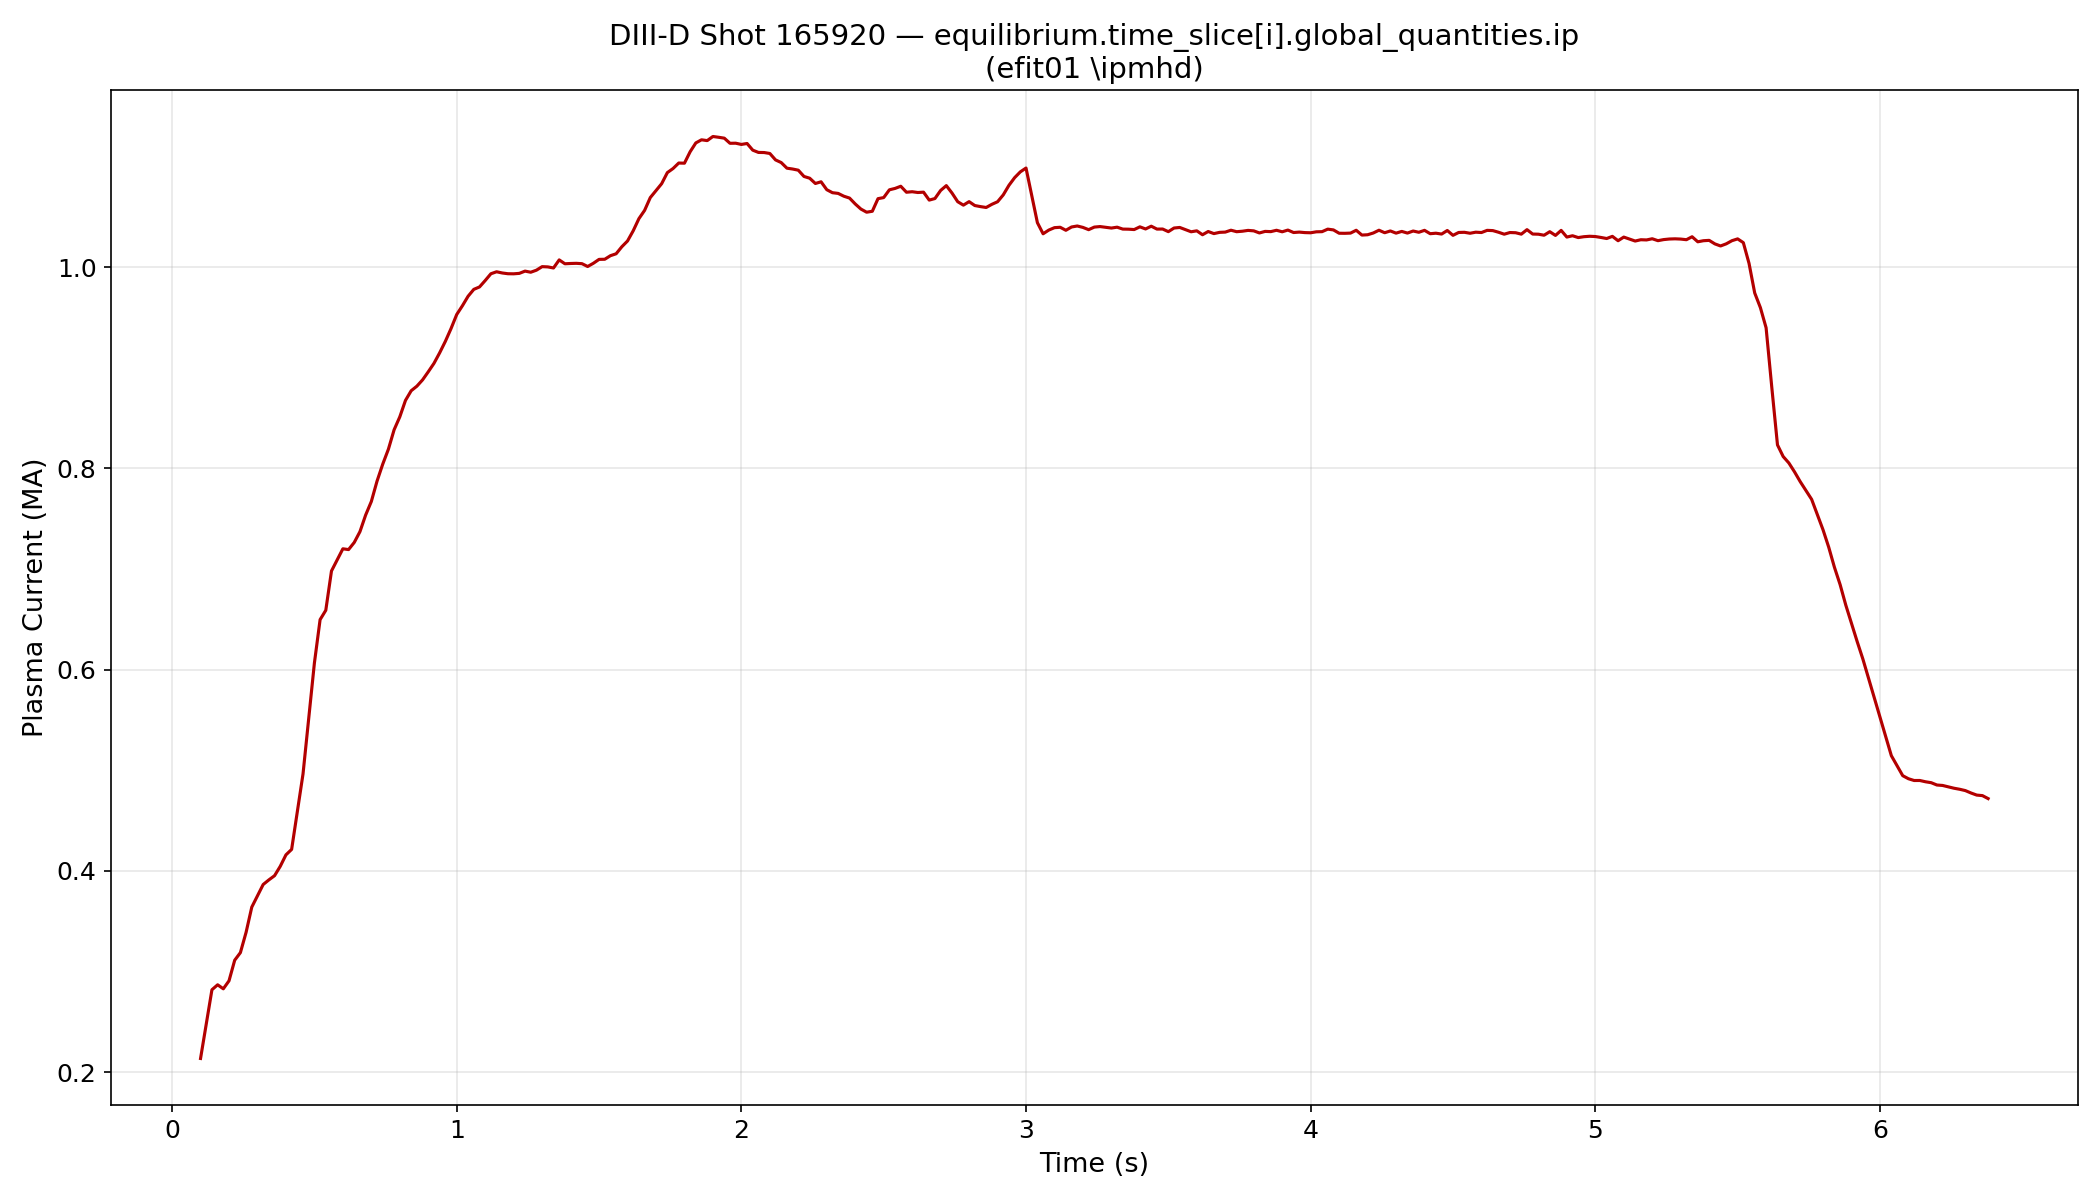

The IMAS Data Dictionary name `equilibrium.time_slice[i].global_quantities.ip` maps directly to the DIII-D EFIT01 plasma current (`\ipmhd` / `CPASMA`) — the `time_slice[i]` index corresponds to each of the 303 EFIT reconstruction time slices spanning the discharge.

In [20]:
%%ask
For DIII-D shot 165920, fetch equilibrium.time_slice[i].global_quantities.ip
and plot it versus time